# Associate manifold analysis

This notebook ingests the `.npz` tensors produced by `experiments/associate_manifold/associate_recorder.py`, reconstructs population activity for area C, and computes the manifold signatures that came out of the associate sweeps.

## Goals

* verify that the geodesic distance between the A and B representations inside C shrinks as the joint-training stages add bridging points
* track local intrinsic dimensionality (LID) around A- and B-selective snapshots
* approximate the pattern-completion rate by measuring how much a B-only `post_B` recall overlaps with the previously A-only assembly, and vice versa
* quantify the "bridge" by comparing shortest-path vs. Euclidean separation and visualizing the low-dimensional embedding

In [84]:
from __future__ import annotations

from pathlib import Path
import json
from typing import Dict, List, Optional, Sequence

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.sparse import coo_matrix, csr_matrix
from scipy.sparse.csgraph import shortest_path
from scipy.spatial import cKDTree
from scipy.spatial.distance import cdist

plt.style.use("seaborn-v0_8")
np.set_printoptions(edgeitems=5, threshold=20)

In [85]:
# -----------------------------------------------------------------------------
# Parameters -- adjust these to point at the sweep(s) you care about
# -----------------------------------------------------------------------------
PROJECT_ROOT = Path.cwd().resolve().parents[1]
RUN_ROOT = PROJECT_ROOT / "runs" / "associate_manifold"
RUN_FILTER: Optional[str] = "paper_scale"  # substring filter; set to None to load everything
MAX_RUNS: Optional[int] = None  # cap the number of run directories, e.g. 6
AREA = "C"
KNN_BASE = 16
KNN_FRACTION = 0.25  # fraction of snapshots to connect
DISTANCE_METRIC = "cosine"  # choices: 'cosine' or 'hamming'
LID_NEIGHBORS = 24
LID_ENERGY = 0.90
print("Run root:", RUN_ROOT)


Run root: /Users/justincharney/zed/assemblies/runs/associate_manifold


In [86]:
CLASS_COLORS = {
    "paired": "#7f7f7f",
    "a_only": "#1f77b4",
    "b_only": "#d62728",
    "post_b": "#ff7f0e",
    "joint": "#9467bd",
    "other": "#8c564b",
}
CLASS_LABELS = {
    "paired": "paired seeds",
    "a_only": "A-only drive",
    "b_only": "B-only drive",
    "post_b": "post-B recall",
    "joint": "joint assoc",
    "other": "other",
}


def classify_stage(label: str) -> str:
    token = label.lower()
    if token.startswith("init") or token.startswith("stabilize"):
        return "paired"
    if token.startswith("seed_a") or token.startswith("a_to_c"):
        return "a_only"
    if token.startswith("seed_b") or token.startswith("b_to_c"):
        return "b_only"
    if token.startswith("joint"):
        return "joint"
    if token.startswith("post_b"):
        return "post_b"
    return "other"


def find_run_dirs(root: Path, substring: Optional[str], limit: Optional[int]) -> List[Path]:
    manifest_files = sorted(root.rglob("manifest.json"))
    run_dirs: List[Path] = []
    for manifest in manifest_files:
        run_dir = manifest.parent
        if substring and substring not in str(run_dir):
            continue
        run_dirs.append(run_dir)
        if limit and len(run_dirs) >= limit:
            break
    return run_dirs


In [87]:
def load_trials(run_dirs: Sequence[Path], area: str) -> Dict[str, Dict[str, object]]:
    trials: Dict[str, Dict[str, object]] = {}
    for run_dir in run_dirs:
        config_path = run_dir / "config.json"
        manifest_path = run_dir / "manifest.json"
        if not config_path.exists() or not manifest_path.exists():
            continue
        with config_path.open("r", encoding="utf-8") as handle:
            config = json.load(handle)
        n_neurons = int(config["n_neurons"])
        with manifest_path.open("r", encoding="utf-8") as handle:
            manifest = json.load(handle)
        run_label = str(run_dir.relative_to(RUN_ROOT))
        for entry in manifest:
            trial_idx = int(entry.get("trial_index", len(manifest)))
            npz_path = run_dir / entry["record_file"]
            if not npz_path.exists():
                continue
            key = f"{run_label}::trial_{trial_idx:03d}"
            snapshots: List[Dict[str, object]] = []
            with np.load(npz_path, allow_pickle=True) as payload:
                times_key = f"{area}_times"
                stages_key = f"{area}_stages"
                idx_key = f"{area}_indices"
                dense_key = f"{area}_dense"
                required = {times_key, stages_key, idx_key}
                missing = [name for name in required if name not in payload.files]
                if missing:
                    raise RuntimeError(
                        f"{npz_path} is missing required keys {missing}; rerun recorder to regenerate."
                    )
                if dense_key not in payload.files:
                    raise RuntimeError(
                        f"{npz_path} lacks '{dense_key}'. Rerun associate_recorder with record_dense=True."
                    )
                times = payload[times_key]
                stages = payload[stages_key]
                winner_lists = payload[idx_key]
                dense_vectors = payload[dense_key]
                if dense_vectors.shape[0] != len(times):
                    raise ValueError(
                        f"Dense payload for {npz_path} has {dense_vectors.shape[0]} rows but expected {len(times)}."
                    )
                for order, (time, stage, winners, dense_vec) in enumerate(
                    zip(times, stages, winner_lists, dense_vectors)
                ):
                    stage_name = str(stage)
                    idx_array = np.asarray(winners, dtype=np.int32)
                    snapshots.append(
                        {
                            "order": order,
                            "time": int(time),
                            "stage": stage_name,
                            "stage_class": classify_stage(stage_name),
                            "indices": idx_array,
                            "dense": np.asarray(dense_vec, dtype=bool),
                        }
                    )
            trials[key] = {
                "key": key,
                "run_path": run_dir,
                "run_label": run_label,
                "trial_index": trial_idx,
                "overlap": float(entry.get("overlap", np.nan)),
                "config": config,
                "snapshots": snapshots,
            }
    return trials


In [88]:
def build_knn_graph(samples: np.ndarray, base_k: int, fraction: float, metric: str) -> csr_matrix:
    n = samples.shape[0]
    if n < 2:
        return csr_matrix((n, n))
    dynamic_k = int(np.ceil(fraction * n))
    target_k = min(max(base_k, dynamic_k), n - 1)
    if target_k <= 0:
        return csr_matrix((n, n))
    distances = cdist(samples, samples, metric=metric)
    np.fill_diagonal(distances, np.inf)
    neighbor_idx = np.argpartition(distances, kth=target_k - 1, axis=1)[:, :target_k]
    rows: List[int] = []
    cols: List[int] = []
    vals: List[float] = []
    for i, neighbors in enumerate(neighbor_idx):
        for j in neighbors:
            dist = float(distances[i, j])
            if not np.isfinite(dist):
                continue
            rows.extend((i, j))
            cols.extend((j, i))
            vals.extend((dist, dist))
    if not rows:
        return csr_matrix((n, n))
    graph = coo_matrix((vals, (rows, cols)), shape=(n, n))
    return graph.tocsr()


def compute_geodesic_timecourse(trial: Dict[str, object], base_k: int, fraction: float, metric: str) -> List[Dict[str, object]]:
    snapshots = trial["snapshots"]
    if not snapshots:
        return []
    samples = np.vstack([snap["dense"].astype(np.float32) for snap in snapshots])
    graph = build_knn_graph(samples, base_k, fraction, metric)
    stage_names = [snap["stage"] for snap in snapshots]
    stage_classes = [snap["stage_class"] for snap in snapshots]
    results: List[Dict[str, object]] = []
    for prefix_end in range(len(snapshots)):
        prefix_slice = slice(0, prefix_end + 1)
        subgraph = graph[prefix_slice, prefix_slice]
        a_nodes = [idx for idx in range(prefix_end + 1) if stage_classes[idx] == "a_only"]
        b_nodes = [
            idx
            for idx in range(prefix_end + 1)
            if stage_classes[idx] in ("b_only", "post_b", "joint")
        ]
        if not a_nodes or not b_nodes:
            results.append(
                {
                    "trial_key": trial["key"],
                    "stage_name": stage_names[prefix_end],
                    "stage_class": stage_classes[prefix_end],
                    "geodesic": np.nan,
                    "euclidean": np.nan,
                    "distortion": np.nan,
                }
            )
            continue
        dist_matrix = shortest_path(subgraph, directed=False, unweighted=False)
        pairwise = dist_matrix[np.ix_(a_nodes, b_nodes)]
        finite = pairwise[np.isfinite(pairwise)]
        geodesic = float(finite.mean()) if finite.size else np.nan
        a_vec = samples[a_nodes].mean(axis=0)
        b_vec = samples[b_nodes].mean(axis=0)
        euclidean = float(np.linalg.norm(a_vec - b_vec))
        distortion = float(geodesic / (euclidean + 1e-8)) if np.isfinite(geodesic) else np.nan
        results.append(
            {
                "trial_key": trial["key"],
                "stage_name": stage_names[prefix_end],
                "stage_class": stage_classes[prefix_end],
                "geodesic": geodesic,
                "euclidean": euclidean,
                "distortion": distortion,
            }
        )
    return results


def compute_local_dimensions(trial: Dict[str, object], neighbors: int, energy: float) -> List[Dict[str, object]]:
    snapshots = trial["snapshots"]
    if not snapshots:
        return []
    samples = np.vstack([snap["dense"].astype(np.float32) for snap in snapshots])
    neighbor_k = min(neighbors + 1, len(snapshots))
    tree = cKDTree(samples)
    _, neighbor_idx = tree.query(samples, k=neighbor_k)
    results: List[Dict[str, object]] = []
    for row_idx, indices in enumerate(neighbor_idx):
        peers = np.asarray(indices[1:], dtype=np.int32)
        if peers.size == 0:
            lid = np.nan
        else:
            neighbor_vectors = samples[peers]
            centered = neighbor_vectors - neighbor_vectors.mean(axis=0, keepdims=True)
            try:
                _, singulars, _ = np.linalg.svd(centered, full_matrices=False)
            except np.linalg.LinAlgError:
                singulars = np.linalg.svd(centered, full_matrices=False, compute_uv=False)
            power = singulars ** 2
            total = power.sum()
            if total <= 0:
                lid = 0.0
            else:
                threshold = energy * total
                lid = float(np.searchsorted(np.cumsum(power), threshold) + 1)
        results.append(
            {
                "trial_key": trial["key"],
                "stage_name": snapshots[row_idx]["stage"],
                "stage_class": snapshots[row_idx]["stage_class"],
                "lid": lid,
            }
        )
    return results


def compute_pattern_completion(trial: Dict[str, object]) -> List[Dict[str, object]]:
    snapshots = trial["snapshots"]
    if not snapshots:
        return []
    stage_classes = [snap["stage_class"] for snap in snapshots]
    joint_start = next((i for i, cls in enumerate(stage_classes) if cls == "joint"), len(stage_classes))
    ref_a = None
    ref_b = None
    for idx, snap in enumerate(snapshots):
        if snap["stage_class"] == "a_only":
            ref_a = snap["dense"]
        if snap["stage_class"] == "b_only" and idx < joint_start:
            ref_b = snap["dense"]
    if ref_a is None or ref_b is None:
        return []
    k = int(trial["config"]["k"])
    results: List[Dict[str, object]] = []
    for snap in snapshots:
        vec = snap["dense"]
        overlap_a = float(np.logical_and(ref_a, vec).sum()) / max(1, k)
        overlap_b = float(np.logical_and(ref_b, vec).sum()) / max(1, k)
        results.append(
            {
                "trial_key": trial["key"],
                "stage_name": snap["stage"],
                "stage_class": snap["stage_class"],
                "overlap_with_a": overlap_a,
                "overlap_with_b": overlap_b,
            }
        )
    return results


def project_pca(trial: Dict[str, object], components: int = 2) -> np.ndarray:
    snapshots = trial["snapshots"]
    if not snapshots:
        return np.zeros((0, components))
    samples = np.vstack([snap["dense"].astype(np.float32) for snap in snapshots])
    centered = samples - samples.mean(axis=0, keepdims=True)
    _, _, vh = np.linalg.svd(centered, full_matrices=False)
    rank = min(components, vh.shape[0])
    basis = vh[:rank].T
    return centered @ basis


In [89]:
def extract_stage_template(trials: Dict[str, Dict[str, object]]):
    if not trials:
        return [], {}
    first_trial = next(iter(trials.values()))
    stage_order = [snap["stage"] for snap in first_trial["snapshots"]]
    stage_classes = {snap["stage"]: snap["stage_class"] for snap in first_trial["snapshots"]}
    return stage_order, stage_classes


def summarize_by_stage(records: List[Dict[str, object]], value_key: str, stage_order: Sequence[str]):
    buckets = {stage: [] for stage in stage_order}
    for record in records:
        stage = record["stage_name"]
        value = record.get(value_key)
        if stage not in buckets or value is None or not np.isfinite(value):
            continue
        buckets[stage].append(float(value))
    summary = []
    for stage in stage_order:
        values = np.asarray(buckets[stage], dtype=float)
        if values.size == 0:
            mean = np.nan
            std = np.nan
        else:
            mean = float(np.nanmean(values))
            std = float(np.nanstd(values))
        summary.append({
            "stage_name": stage,
            "mean": mean,
            "std": std,
        })
    return summary


def plot_stage_summary(summary, stage_classes, ylabel, title, ylim=None):
    if not summary:
        print("Nothing to plot")
        return
    x = np.arange(len(summary))
    y = np.array([entry["mean"] for entry in summary], dtype=float)
    yerr = np.array([entry["std"] for entry in summary], dtype=float)
    colors = [CLASS_COLORS.get(stage_classes.get(entry["stage_name"], "other"), "#333333") for entry in summary]
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.errorbar(x, y, yerr=yerr, fmt="-o", color="#1f77b4", ecolor="#1f77b4", capsize=3, alpha=0.6)
    ax.scatter(x, y, c=colors, s=55, edgecolor="white", linewidth=0.7, zorder=5)
    ax.set_xticks(x, [entry["stage_name"] for entry in summary], rotation=90)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.2)
    if ylim is not None:
        ax.set_ylim(*ylim)
    seen = []
    for entry in summary:
        cls = stage_classes.get(entry["stage_name"], "other")
        if cls not in seen and cls in CLASS_COLORS:
            seen.append(cls)
    handles = [Patch(color=CLASS_COLORS[c], label=CLASS_LABELS.get(c, c)) for c in seen]
    if handles:
        ax.legend(handles=handles, title="stage class", loc="upper right", bbox_to_anchor=(1.12, 1))
    plt.tight_layout()


def plot_pattern_series(summary_a, summary_b, stage_classes):
    if not summary_a or not summary_b:
        print("Pattern completion summary missing")
        return
    x = np.arange(len(summary_a))
    y_a = np.array([entry["mean"] for entry in summary_a], dtype=float)
    y_b = np.array([entry["mean"] for entry in summary_b], dtype=float)
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(x, y_a, "-o", color=CLASS_COLORS["a_only"], label="overlap vs. A-only ref")
    ax.plot(x, y_b, "-o", color=CLASS_COLORS["b_only"], label="overlap vs. B-only ref")
    ax.set_xticks(x, [entry["stage_name"] for entry in summary_a], rotation=90)
    ax.set_ylabel("normalized overlap")
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.2)
    ax.set_title("Pattern-completion proxy inside C")
    ax.legend(loc="upper right")
    plt.tight_layout()

In [90]:
run_dirs = find_run_dirs(RUN_ROOT, RUN_FILTER, MAX_RUNS)
print(f"Found {len(run_dirs)} run directories")
trials = load_trials(run_dirs, AREA)
print(f"Loaded {len(trials)} trials for area {AREA}")
if trials:
    stage_order, stage_classes = extract_stage_template(trials)
    print(f"Stage timeline length: {len(stage_order)}")
else:
    stage_order, stage_classes = [], {}

Found 9 run directories
Loaded 9 trials for area C
Stage timeline length: 67


In [91]:
geodesic_records: List[Dict[str, object]] = []
lid_records: List[Dict[str, object]] = []
pattern_records: List[Dict[str, object]] = []
for trial in trials.values():
    geodesic_records.extend(
        compute_geodesic_timecourse(trial, KNN_BASE, KNN_FRACTION, DISTANCE_METRIC)
    )
    lid_records.extend(compute_local_dimensions(trial, LID_NEIGHBORS, LID_ENERGY))
    pattern_records.extend(compute_pattern_completion(trial))
print(f"Geodesic samples: {len(geodesic_records)}")
print(f"LID samples: {len(lid_records)}")
print(f"Pattern completion samples: {len(pattern_records)}")


Geodesic samples: 603
LID samples: 603
Pattern completion samples: 603


### Geodesic distance between A and B traces inside C

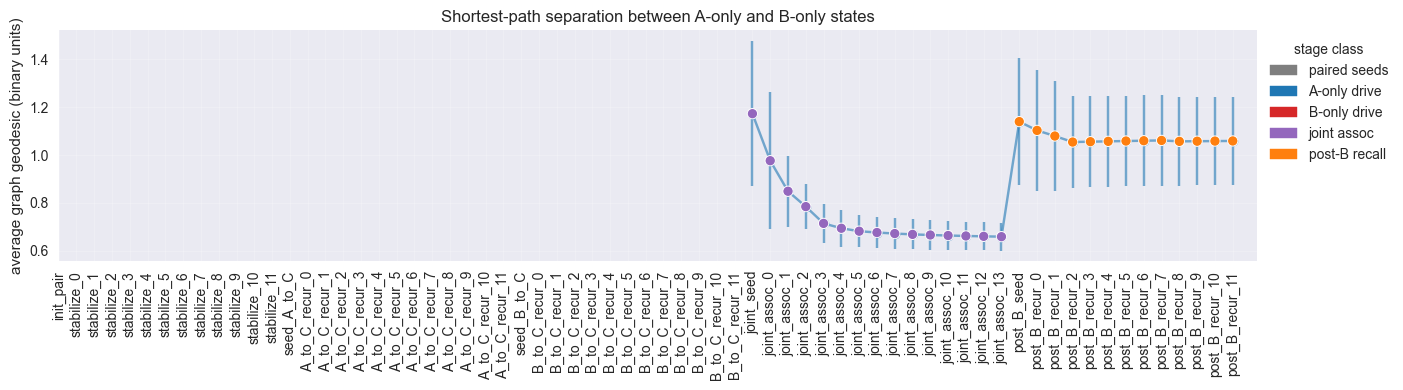

In [98]:
geodesic_summary = summarize_by_stage(geodesic_records, "geodesic", stage_order)
euclidean_summary = summarize_by_stage(geodesic_records, "euclidean", stage_order)
plot_stage_summary(
    geodesic_summary,
    stage_classes,
    ylabel="average graph geodesic (binary units)",
    title="Shortest-path separation between A-only and B-only states",
)


#### Joint-stage bridge detail
Focus on the joint A+B projections to make it obvious how the graph geodesic collapses while the two assemblies intertwine inside C.

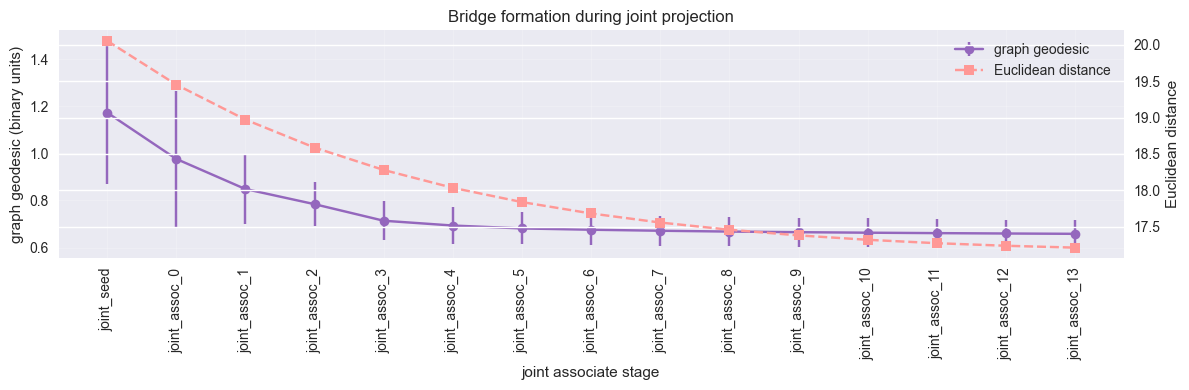

In [99]:
joint_stage_names = [name for name in stage_order if stage_classes.get(name) == "joint"]
if joint_stage_names:
    geo_map = {entry["stage_name"]: entry for entry in geodesic_summary}
    euc_map = {entry["stage_name"]: entry for entry in euclidean_summary}
    x = np.arange(len(joint_stage_names))
    g_mean = np.array([geo_map.get(name, {}).get("mean", np.nan) for name in joint_stage_names], dtype=float)
    g_std = np.array([geo_map.get(name, {}).get("std", np.nan) for name in joint_stage_names], dtype=float)
    e_mean = np.array([euc_map.get(name, {}).get("mean", np.nan) for name in joint_stage_names], dtype=float)
    fig, ax1 = plt.subplots(figsize=(12, 4))
    ax1.errorbar(
        x,
        g_mean,
        yerr=g_std,
        fmt="-o",
        capsize=3,
        color=CLASS_COLORS["joint"],
        label="graph geodesic",
    )
    ax1.set_xticks(x, joint_stage_names, rotation=90)
    ax1.set_ylabel("graph geodesic (binary units)")
    ax1.grid(True, alpha=0.2)
    ax1.set_xlabel("joint associate stage")
    ax1.set_title("Bridge formation during joint projection")
    ax2 = ax1.twinx()
    ax2.plot(x, e_mean, "--s", color="#ff9896", label="Euclidean distance")
    ax2.set_ylabel("Euclidean distance")
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
    plt.tight_layout()
else:
    print("No joint stages available for bridge visualization")


### Graph-vs-Euclidean distortion (bridge score)

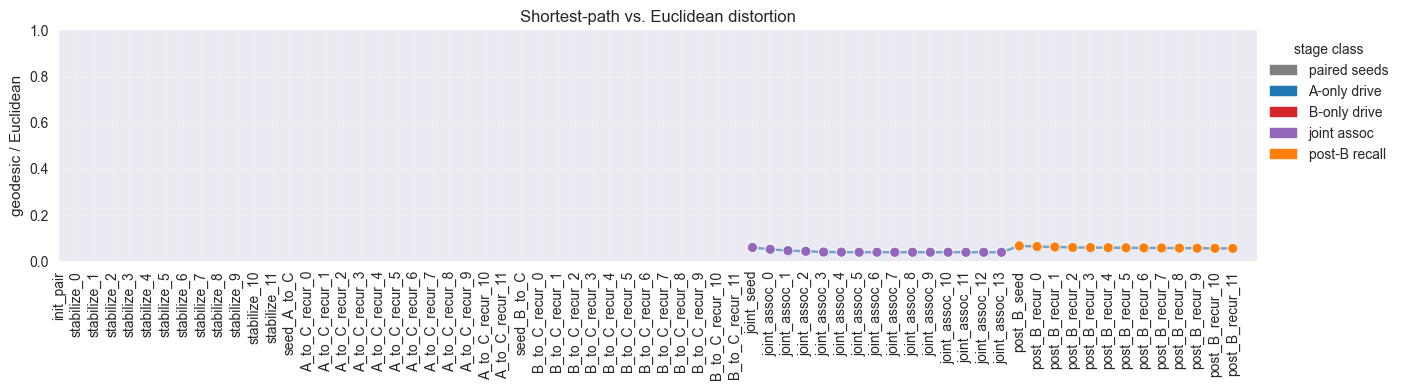

In [93]:
distortion_summary = summarize_by_stage(geodesic_records, "distortion", stage_order)
means = np.array([entry["mean"] for entry in distortion_summary], dtype=float)
finite = means[np.isfinite(means)]
limit = max(1.0, float(finite.max()) * 1.1) if finite.size else 1.0
plot_stage_summary(
    distortion_summary,
    stage_classes,
    ylabel="geodesic / Euclidean",
    title="Shortest-path vs. Euclidean distortion",
    ylim=(0, limit),
)


### Local intrinsic dimensionality

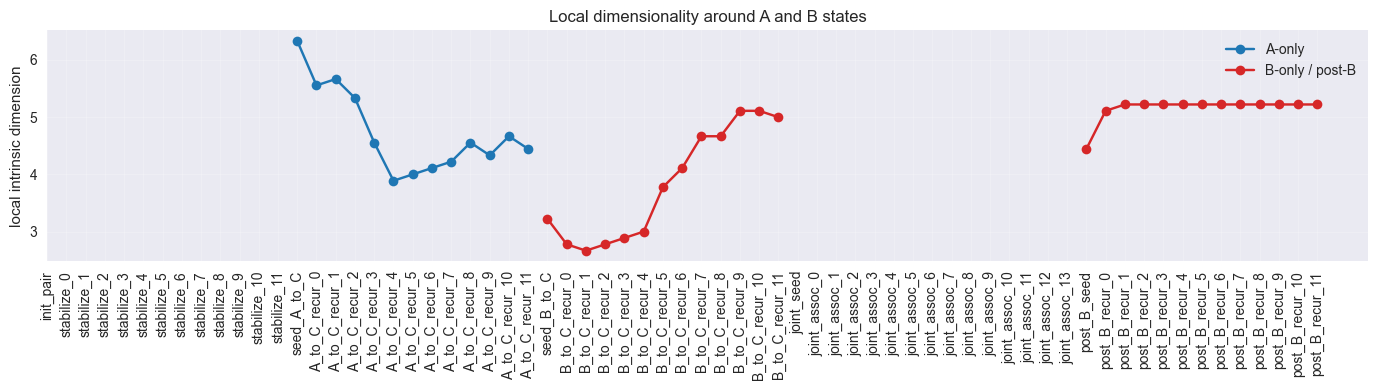

In [94]:
lid_a = [record for record in lid_records if record["stage_class"] == "a_only"]
lid_b = [record for record in lid_records if record["stage_class"] in ("b_only", "post_b")]
lid_summary_a = summarize_by_stage(lid_a, "lid", stage_order)
lid_summary_b = summarize_by_stage(lid_b, "lid", stage_order)
if lid_summary_a or lid_summary_b:
    x = np.arange(len(stage_order))
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(x, [entry["mean"] for entry in lid_summary_a], "-o", label="A-only", color=CLASS_COLORS["a_only"])
    ax.plot(x, [entry["mean"] for entry in lid_summary_b], "-o", label="B-only / post-B", color=CLASS_COLORS["b_only"])
    ax.set_xticks(x, stage_order, rotation=90)
    ax.set_ylabel("local intrinsic dimension")
    ax.set_title("Local dimensionality around A and B states")
    ax.grid(True, alpha=0.2)
    ax.legend(loc="upper right")
    plt.tight_layout()
else:
    print("No LID samples to plot")

### Pattern-completion proxy

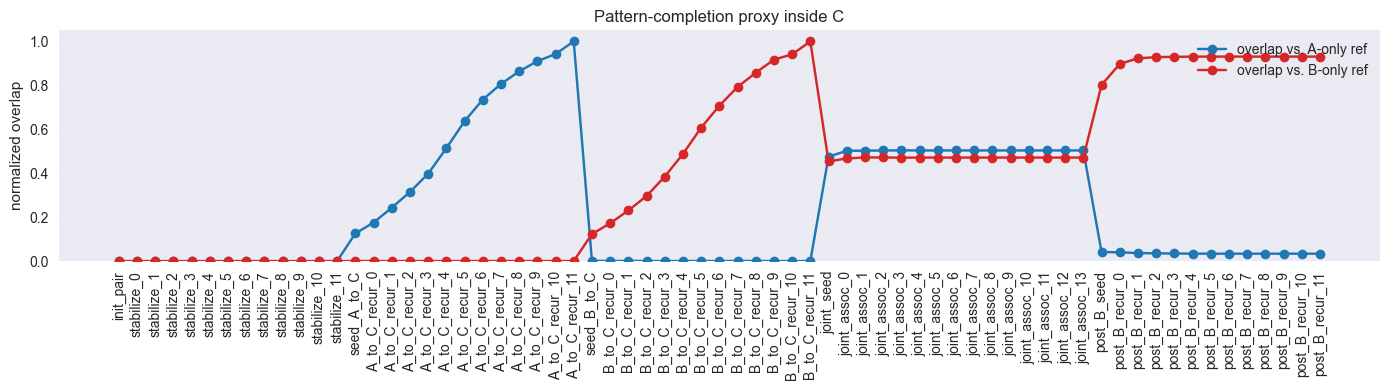

In [95]:
pattern_summary_a = summarize_by_stage(pattern_records, "overlap_with_a", stage_order)
pattern_summary_b = summarize_by_stage(pattern_records, "overlap_with_b", stage_order)
plot_pattern_series(pattern_summary_a, pattern_summary_b, stage_classes)

### PCA view of one trial

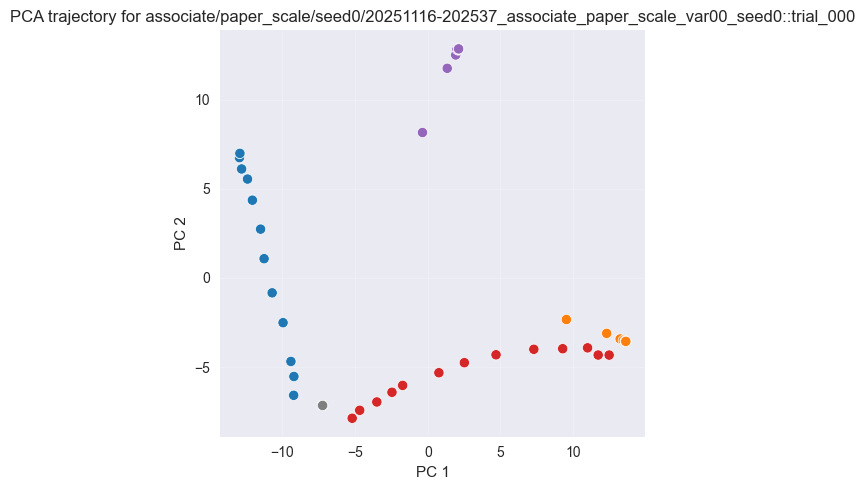

In [96]:
if trials:
    example_key = next(iter(trials))
    example_trial = trials[example_key]
    embedding = project_pca(example_trial, components=2)
    colors = [CLASS_COLORS.get(snap["stage_class"], "#333333") for snap in example_trial["snapshots"]]
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(embedding[:, 0], embedding[:, 1], c=colors, s=55, edgecolor="white", linewidth=0.5)
    ax.set_title(f"PCA trajectory for {example_key}")
    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
else:
    print("No trials loaded")